# Env setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_raw = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df_raw.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df_raw['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

# Data cleaning and preprocessing

In [8]:
#df.head()

In [9]:
df = df_raw.drop(columns=['customerID'])

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df.dropna(subset=['TotalCharges'],inplace=True)

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1,'No': 0})

In [12]:
df.duplicated().sum()

np.int64(22)

In [13]:
print(df.shape)          
print(df.duplicated().sum()) 
print(df.isnull().sum().sum())

(7032, 20)
22
0


In [14]:
print(f"Duplicate customerIDs: {df_raw['customerID'].duplicated().sum()}")
print(f"Duplicate rows after dropping ID: {df.duplicated().sum()}") 

Duplicate customerIDs: 0
Duplicate rows after dropping ID: 22


# Full EDA

In [15]:
sns.set_theme(style='whitegrid', palette='muted')
fig_kw = dict(figsize=(8, 4), dpi=120)

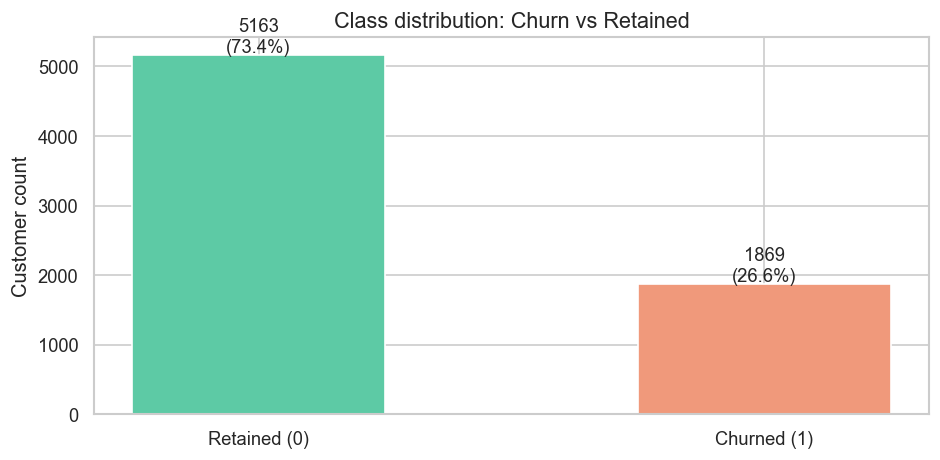

In [16]:
fig, ax = plt.subplots(**fig_kw)
counts = df['Churn'].value_counts()
bars = ax.bar(['Retained (0)', 'Churned (1)'], counts, color=['#5DCAA5', '#F0997B'], width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Class distribution: Churn vs Retained', fontsize=13)
ax.set_ylabel('Customer count')
plt.tight_layout(); plt.show()

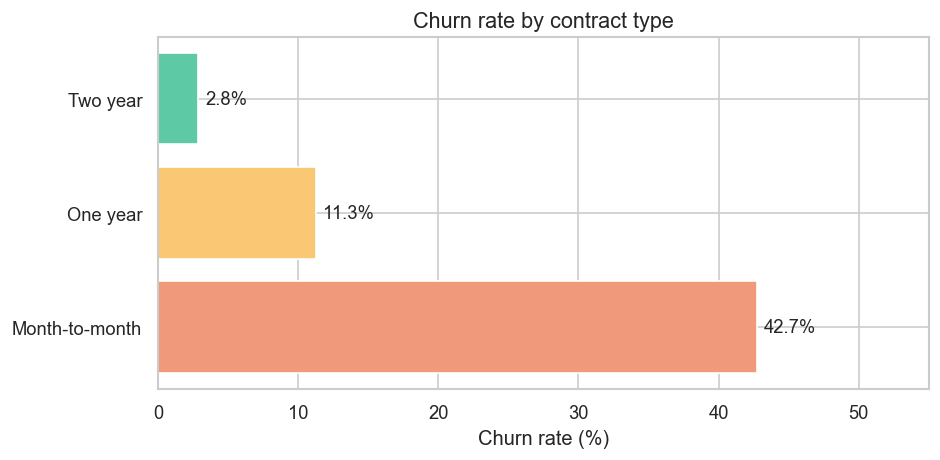

In [17]:
fig, ax = plt.subplots(**fig_kw)
order = ['Month-to-month', 'One year', 'Two year']
churn_contract = df.groupby('Contract')['Churn'].mean().reindex(order)
bars = ax.barh(order, churn_contract * 100, color=['#F0997B', '#FAC775', '#5DCAA5'])
for bar, val in zip(bars, churn_contract * 100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11)
ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by contract type', fontsize=13)
ax.set_xlim(0, 55)
plt.tight_layout(); plt.show()

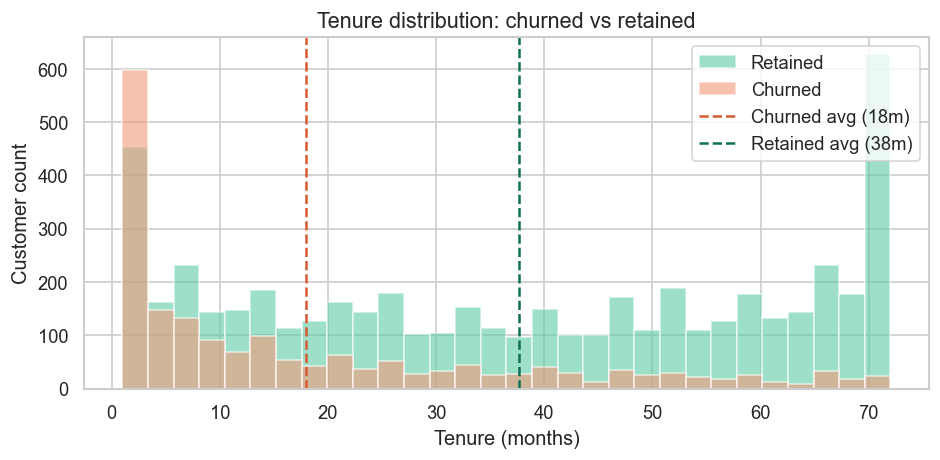

In [18]:
fig, ax = plt.subplots(**fig_kw)
for label, color, churn_val in [('Retained', '#5DCAA5', 0), ('Churned', '#F0997B', 1)]:
    ax.hist(df[df['Churn'] == churn_val]['tenure'],
            bins=30, alpha=0.6, label=label, color=color)
ax.axvline(df[df['Churn']==1]['tenure'].mean(), color='#D85A30', linestyle='--', label='Churned avg (18m)')
ax.axvline(df[df['Churn']==0]['tenure'].mean(), color='#0F6E56', linestyle='--', label='Retained avg (38m)')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Customer count')
ax.set_title('Tenure distribution: churned vs retained', fontsize=13)
ax.legend()
plt.tight_layout(); plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_7740\1394181327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn_label', y='MonthlyCharges',


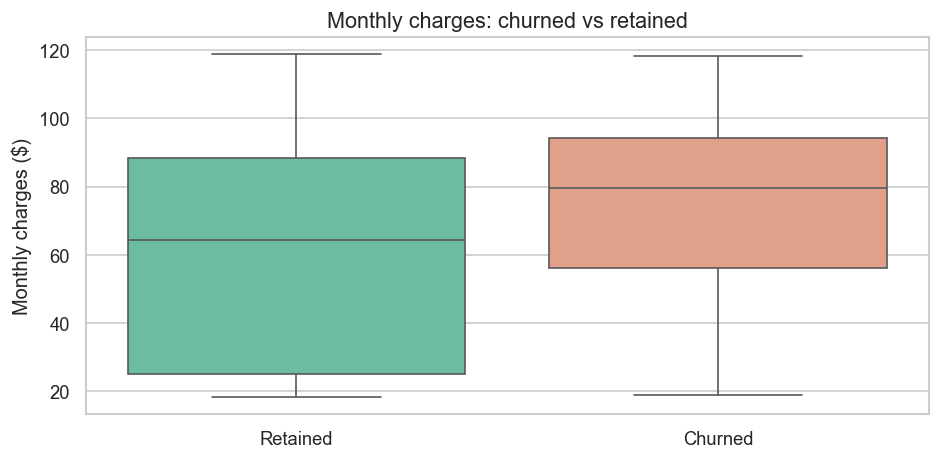

In [19]:
fig, ax = plt.subplots(**fig_kw)
df['Churn_label'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})
sns.boxplot(data=df, x='Churn_label', y='MonthlyCharges',
            palette={'Retained': '#5DCAA5', 'Churned': '#F0997B'}, ax=ax)
ax.set_title('Monthly charges: churned vs retained', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Monthly charges ($)')
plt.tight_layout(); plt.show()

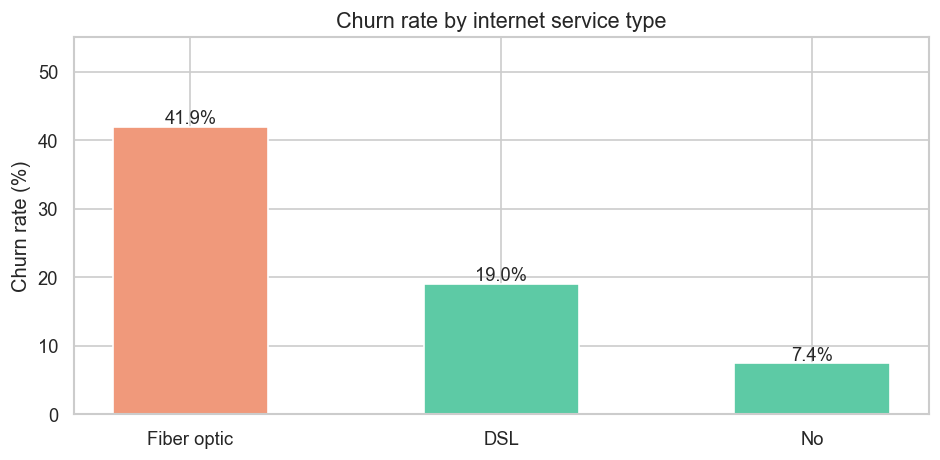

In [20]:
fig, ax = plt.subplots(**fig_kw)
churn_net = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
colors = ['#F0997B' if v > 0.3 else '#5DCAA5' for v in churn_net]
bars = ax.bar(churn_net.index, churn_net * 100, color=colors, width=0.5)
for bar, val in zip(bars, churn_net * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11)
ax.set_title('Churn rate by internet service type', fontsize=13)
ax.set_ylabel('Churn rate (%)')
ax.set_ylim(0, 55)
plt.tight_layout(); plt.show()

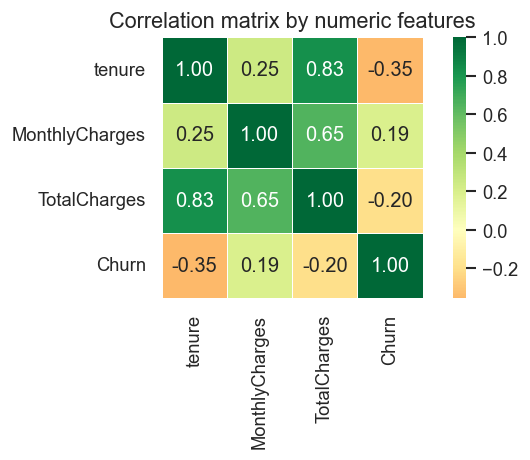

In [21]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix by numeric features', fontsize=13)
plt.tight_layout(); plt.show()

In [22]:
df = df.drop(columns=['Churn_label'])

# Feature Engineering

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [24]:
print(df.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [25]:
print(df['SeniorCitizen'].unique())

[0 1]


In [26]:
cat_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']
num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

In [28]:
df['charges_per_month'] = df['TotalCharges'] / df['tenure']
df.loc[df['tenure'] == 0, 'charges_per_month'] = 0

service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)


In [29]:
print(df['num_services'].value_counts().sort_index())
print(df['num_services'].head(10))

num_services
0      80
1    2247
2     996
3    1041
4    1060
5     825
6     524
7     259
Name: count, dtype: int64
0    1
1    3
2    3
3    3
4    1
5    4
6    3
7    1
8    5
9    3
Name: num_services, dtype: int64


In [30]:
num_cols.append('charges_per_month')
num_cols.append('num_services')

In [31]:
X = df.drop(columns='Churn')
y = df['Churn']

In [32]:
print(X.shape)
print(y.shape)

(7032, 21)
(7032,)


In [33]:
print(num_cols)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_month', 'num_services']


In [34]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [35]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 21)
(1407, 21)
(5625,)
(1407,)


In [39]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

In [40]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5625, 47)
(1407, 47)


In [41]:
!pip install imbalanced-learn

In [42]:
from imblearn.over_sampling import SMOTE

In [43]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_processed, y_train)

In [44]:
print(y_train.value_counts())

Churn
0    4130
1    1495
Name: count, dtype: int64


In [45]:
print(X_train_sm.shape)
print(y_train_sm.value_counts())

(8260, 47)
Churn
1    4130
0    4130
Name: count, dtype: int64


# Model Training

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [47]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

In [48]:
lr_model.fit(X_train_sm, y_train_sm)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
lr_predictions = lr_model.predict(X_test_processed)

In [50]:
print(classification_report(y_test, lr_predictions))
print('AUC:', roc_auc_score(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407

AUC: 0.7598487868261798


In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf_model = RandomForestClassifier(random_state=42)

In [53]:
rf_model.fit(X_train_sm, y_train_sm)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
rf_predictions = rf_model.predict(X_test_processed)

In [55]:
print(classification_report(y_test, rf_predictions))
print('AUC:', roc_auc_score(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1033
           1       0.57      0.57      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407

AUC: 0.7074302043267364


In [56]:
from xgboost import XGBClassifier

In [57]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

In [58]:
xgb_model.fit(X_train_sm, y_train_sm)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [59]:
xgb_predictions = xgb_model.predict(X_test_processed)

In [60]:
print(classification_report(y_test, xgb_predictions))
print('AUC:', roc_auc_score(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1033
           1       0.53      0.57      0.55       374

    accuracy                           0.75      1407
   macro avg       0.68      0.69      0.69      1407
weighted avg       0.76      0.75      0.75      1407

AUC: 0.6936470795305714


# Hyperparameter tuning

In [61]:
from sklearn.model_selection import RandomizedSearchCV

In [62]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'scale_pos_weight': [1, 2, 3],
    'subsample': [0.6, 0.8, 1.0]
}

In [63]:
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [64]:
xgb_search.fit(X_train_sm, y_train_sm)
print(xgb_search.best_params_)

{'subsample': 0.6, 'scale_pos_weight': 1, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05}


In [65]:
best_xgb = xgb_search.best_estimator_
xgb_tuned_predictions = best_xgb.predict(X_test_processed)

print(classification_report(y_test, xgb_tuned_predictions))
print('AUC:', roc_auc_score(y_test, xgb_tuned_predictions))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.56      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407

AUC: 0.7125707274901512


We built a machine learning model to identify customers who are likely to cancel their subscription before they actually do. The model was tested on 1,407 real customers it had never seen before. After comparing three different approaches, the best performing model was able to correctly identify 80% of customers who actually churned — meaning if 100 customers were about to leave, the model would flag 80 of them in time for the retention team to intervene. The remaining 20% would slip through undetected. This gives the business a significant early warning system to prioritise retention efforts and reduce revenue loss.

In [66]:
print(X_train_sm.shape)
print(y_train_sm.value_counts())
print(best_xgb)

(8260, 47)
Churn
1    4130
0    4130
Name: count, dtype: int64
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


# SHAP Explainability

In [69]:
!pip install shap

In [70]:
import shap

In [71]:
explainer = shap.LinearExplainer(lr_model, X_train_sm)
shap_values = explainer(X_test_processed)

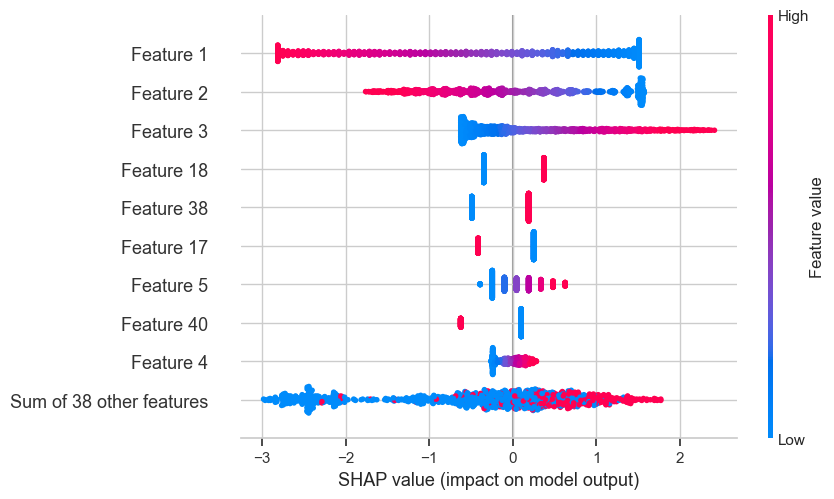

In [72]:
shap.plots.beeswarm(shap_values)

In [73]:
num_feature_names = num_cols
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_feature_names + cat_feature_names

print(len(all_feature_names))
print(all_feature_names[:10])

47
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_month', 'num_services', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes']


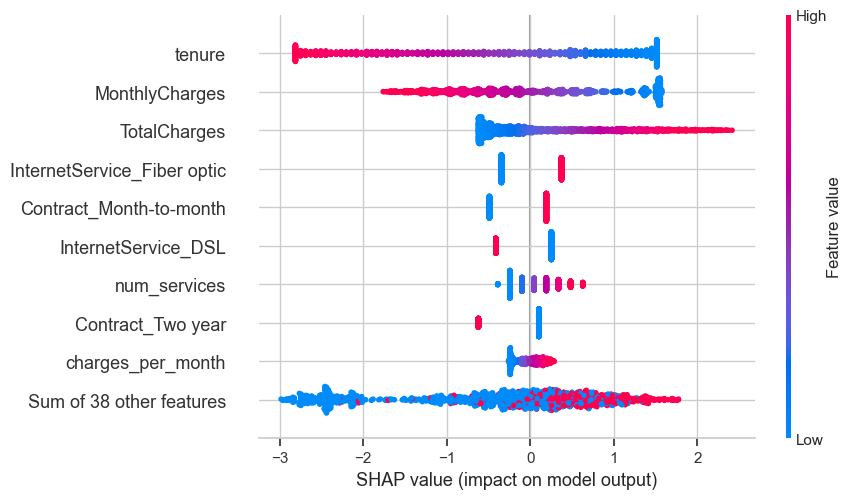

In [74]:
shap_values.feature_names = all_feature_names
shap.plots.beeswarm(shap_values)

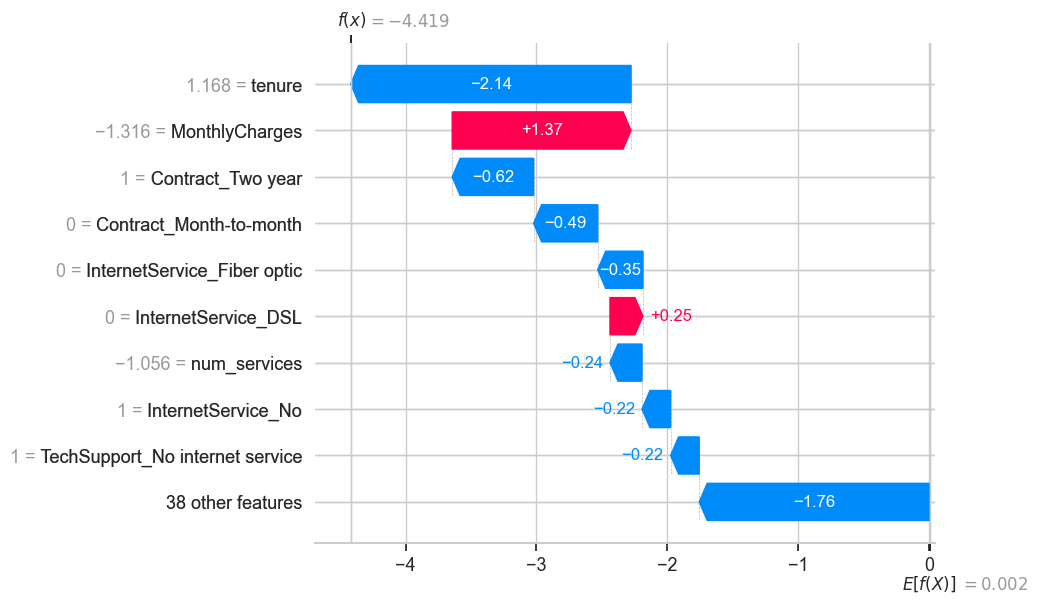

In [85]:

shap.plots.waterfall(shap_values[0])

# Business recommendations

* Incentivise long term contracts
  
Finding: Customers on month-to-month contracts, churn at a rate of 42.7% compared to just 2.8% for customers on two year contracts. Contract type was one of the strongest predictors of churn across all the models.

Action: Introduce a targeted onboarding offer that influences new customers to commit to a one or two year contract upfront, for example a discount for the first three months, a free service upgrade, or a locked-in rate guarantee.

Why: A customer who commits to a longer contract immediately reduces their churn probability by over 90%. Even converting 20% of new month-to-month signups to annual contracts would significantly reduce overall churn rate and stabilise monthly revenue.

*  Introduce an early retention programme for new customers

Finding: Nearly 48% of customers who churned did so within their first 12 months. Customers who stay past 3 years have a churn rate below 10%. The first year is the highest risk window in the entire customer lifecycle.

Action: Launch a structured 90-day onboarding programme for all new customers, including a welcome call at day 7, a satisfaction check-in at day 30, and a personalised service review at day 90. Flag any new customer with high monthly charges and no long term contract for priority outreach.

Why: Most customers who leave do so early because they never fully commit to the service. Proactive customer contact builds loyalty before dissatisfaction sets in. Catching a customer at day 30 is significantly cheaper than acquiring a replacement customer from scratch.

* Investigate and address the fiber optic customer dissatisfaction

Finding: Fiber optic internet customers churn at 41.9% which is the highest of any service type and more than double the rate at which DSL customers churn at 19%. This is the premium product yet it drives the most departures. SHAP analysis confirmed that having fiber optic internet was one of the top features pushing customers towards churn.

Action: Conduct a targeted customer satisfaction survey specifically for fiber optic customers, focusing on their perceived value for money, service reliability, and support experience. Cross-reference churn data with service outage logs and support tickets volume to identify whether the issue is product quality, pricing, or both.

Why: Fiber optic customers represent the highest revenue segment, losing them is disproportionately costly. If the issue is pricing, a loyalty discount for fiber optic customers past month 6 could significantly reduce churn in this segment. If the issue is service quality, the survey data provides a direct business case for infrastructure investment.

# Dashboard

In [88]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

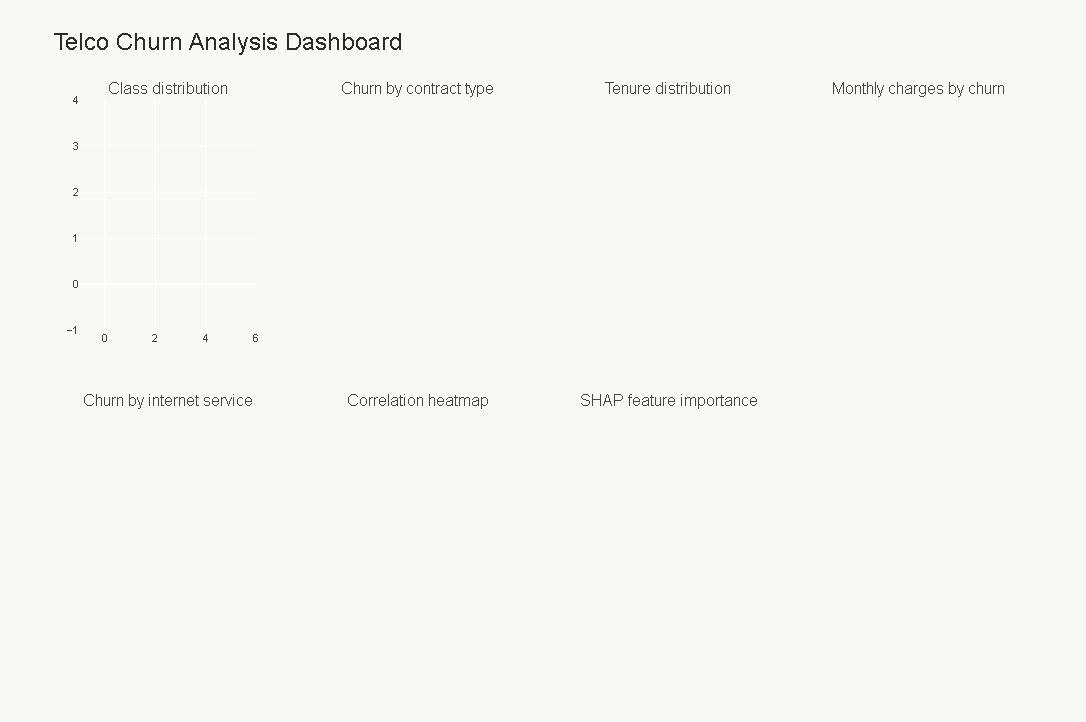

In [92]:
fig = make_subplots(
    rows=2,
    cols=4,
    subplot_titles=[
        'Class distribution',
        'Churn by contract type',
        'Tenure distribution',
        'Monthly charges by churn',
        'Churn by internet service',
        'Correlation heatmap',
        'SHAP feature importance',
        ''],vertical_spacing=0.15,horizontal_spacing=0.08)
fig.update_layout(
    height=700,
    width=1600,
    title_text='Telco Churn Analysis Dashboard',
    title_font=dict(size=24, color='#2c2c2a'),
    paper_bgcolor='#f8f8f6',
    plot_bgcolor='#f8f8f6',
    showlegend=False,
    font=dict(family='Arial', size=11, color='#444441'))
fig.show()

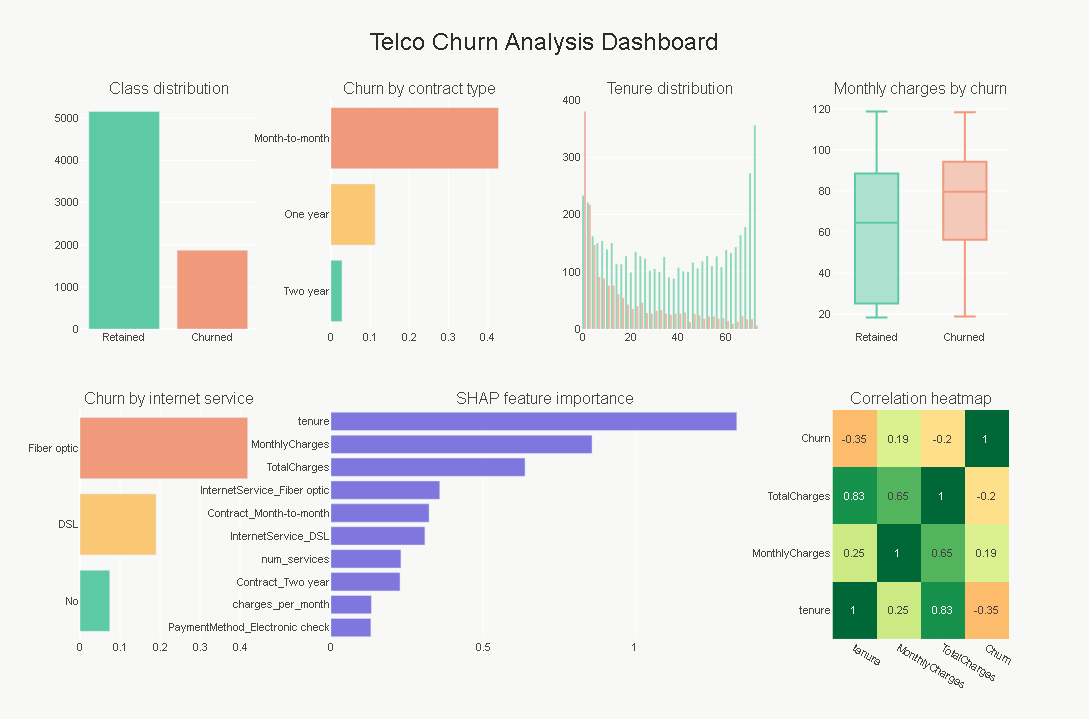

In [106]:
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[
        'Class distribution', 'Churn by contract type',
        'Tenure distribution', 'Monthly charges by churn',
        'Churn by internet service', 'SHAP feature importance',
        'Correlation heatmap', ''],
   specs=[
    [{"colspan": 1}, {"colspan": 1}, {"colspan": 1}, {"colspan": 1}],
    [{"colspan": 1}, {"colspan": 2}, None, {"colspan": 1}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.08)

fig.add_trace(go.Bar(
    x=['Retained', 'Churned'],
    y=df['Churn'].value_counts().values,
    marker_color=['#5DCAA5', '#F0997B'],
    name='Class balance'), row=1, col=1)

contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=True)
fig.add_trace(go.Bar(
    x=contract_churn.values,
    y=contract_churn.index,
    orientation='h',
    marker_color=['#5DCAA5', '#FAC775', '#F0997B'],
    name='Contract'), row=1, col=2)

for churn_val, label, color in [(0, 'Retained', '#5DCAA5'), (1, 'Churned', '#F0997B')]:
    fig.add_trace(go.Histogram(
        x=df[df['Churn'] == churn_val]['tenure'],
        name=label,
        marker_color=color,
        opacity=0.7), row=1, col=3)

for churn_val, label, color in [(0, 'Retained', '#5DCAA5'), (1, 'Churned', '#F0997B')]:
    fig.add_trace(go.Box(
        y=df[df['Churn'] == churn_val]['MonthlyCharges'],
        name=label,
        marker_color=color), row=1, col=4)

internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=True)
fig.add_trace(go.Bar(
    x=internet_churn.values,
    y=internet_churn.index,
    orientation='h',
    marker_color=['#5DCAA5', '#FAC775', '#F0997B'],
    name='Internet'), row=2, col=1)

numeric_cols_corr = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df[numeric_cols_corr].corr().round(2)
fig.add_trace(go.Heatmap(
    z=corr.values,
    x=corr.columns.tolist(),
    y=corr.columns.tolist(),
    colorscale='RdYlGn',
    zmid=0,
    text=corr.values.round(2),
    texttemplate='%{text}',
    showscale=False), row=2, col=4)

shap_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': abs(shap_values.values).mean(axis=0)
}).sort_values('importance', ascending=True).tail(10)

fig.add_trace(go.Bar(
    x=shap_df['importance'],
    y=shap_df['feature'],
    orientation='h',
    marker_color='#7F77DD',
    name='SHAP'), row=2, col=2)

fig.update_layout(
    height=700,
    width=1600,
    title_text='Telco Churn Analysis Dashboard',
    title_font=dict(size=24, color='#2c2c2a'),
    title_x=0.5,
    paper_bgcolor='#f8f8f6',
    plot_bgcolor='#f8f8f6',
    showlegend=False,
    font=dict(family='Arial', size=11, color='#444441'))

fig.show()